In [178]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [179]:
df = pd.read_csv(r'c:\Users\owenr\OneDrive\qb_data.csv')

In [180]:
df.head()

,player_name,completion_pct_y1,yds_y1,td_y1,int_y1,passer_rating_y1,passer_rating_y2,Class,Amount
0,C.J. Stroud,63.9,4108,23,5,100.8,98.4,0,-2.4
1,Bryce Young,59.8,2877,11,10,73.7,79.1,1,5.4
2,Trevor Lawrence,59.6,3641,12,17,71.9,95.2,1,23.3
3,Justin Fields,58.9,1870,7,10,73.2,85.2,1,12.0
4,Mac Jones,67.6,3801,22,13,92.5,84.8,0,-7.7


In [181]:
df.columns

Index(['player_name', 'completion_pct_y1', 'yds_y1', 'td_y1', 'int_y1',
       'passer_rating_y1', 'passer_rating_y2', 'Class', 'Amount'],
      dtype='object')

In [182]:
X = df[['completion_pct_y1', 'yds_y1', 'td_y1', 'int_y1', 'passer_rating_y1']]

In [183]:
y = df['Class']

In [184]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [185]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [186]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8


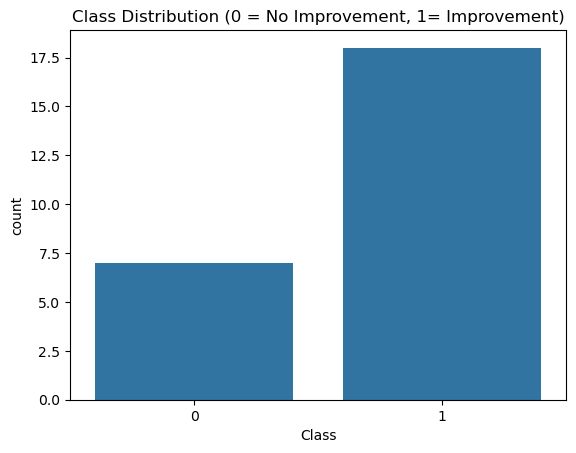

In [187]:
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0 = No Improvement, 1= Improvement)")
plt.show()

In [188]:
print(f"Cam Ward Predicted Improvement Class: {will_improve} ({'Will Improve' if will_improve == 1 else 'Will Not Improve'})")

Cam Ward Predicted Improvement Class: 1 (Will Improve)


In [189]:
cam_ward = pd.DataFrame([[60.5, 3100, 18, 10, 85.0]], columns=X.columns)
print(f"Cam Ward Year 2 Performance: {model.predict(cam_ward)[0]:.1f}")

Cam Ward Year 2 Performance: 1.0


In [198]:
X = df[['completion_pct_y1', 'yds_y1', 'td_y1', 'int_y1', 'passer_rating_y1']]
y = df['Amount']

In [197]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [200]:
regressor = DecisionTreeRegressor(max_depth=3, random_state=42)
regressor.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [194]:
cam_ward_input = pd.DataFrame([[60.5, 3100, 18, 10, 85.0]], columns=X.columns)
predicted_improvement = regressor.predict(cam_ward_input)[0]

In [195]:
print(f"Predicted Passer Rating Improvement: {predicted_improvement:+.1f} points")
print(f"Projected Year 2 Passer Rating: {85.0 + predicted_improvement:.1f}")

Predicted Passer Rating Improvement: +6.0 points
Projected Year 2 Passer Rating: 91.0
